https://www.kaggle.com/datasets/vishakhdapat/customer-segmentation-clustering

Bộ dataset "Customer Segmentation : Clustering" trên Kaggle (do tài khoản Vishakh Dapat chia sẻ) thực chất là một bộ dữ liệu cổ điển và rất phổ biến dùng cho các bài toán Phân cụm khách hàng (Customer Segmentation) bằng thuật toán học máy không giám sát (Unsupervised Learning), điển hình như K-Means Clustering

Annual Income (k$):   Ý nghĩa: Thu nhập hằng năm của khách hàng (được tính bằng nghìn đô-la, ví dụ: $15k, $50k, $120k...).   Vai trò: Là một trong những biến số quan trọng nhất để gom cụm, giúp doanh nghiệp nhận biết khách hàng thuộc phân khúc thu nhập thấp, trung bình hay cao.   Spending Score (1-100):   Ý nghĩa: Điểm chi tiêu / Điểm mua sắm do cửa hàng/hệ thống chấm dựa trên hành vi và mức độ thường xuyên mua hàng của khách hàng (thang điểm từ 1 đến 100).   Điểm số càng cao nghĩa là khách hàng đó càng hào phóng, chi tiêu nhiều hoặc mua sắm liên tục.   Điểm số thấp nghĩa là khách hàng tiết kiệm, ít mua sắm.

2. Mục đích chính khi phân tích bộ dataset nàyMục tiêu cốt lõi của việc sử dụng dataset này là giúp doanh nghiệp gom nhóm khách hàng có các đặc tính giống nhau vào cùng một cụm (Cluster) thông qua các thuật toán như K-Means, từ đó:   Xác định khách hàng mục tiêu: Nhận diện nhóm khách hàng nào vừa có Thu nhập cao vừa có Điểm chi tiêu cao (khách hàng "VIP" cần chăm sóc đặc biệt).Chiến lược Marketing cá nhân hóa:Nhóm thu nhập cao nhưng chi tiêu thấp $\rightarrow$ Tìm cách kích cầu, tung ra các chương trình ưu đãi độc quyền.Nhóm thu nhập thấp nhưng điểm chi tiêu cao $\rightarrow$ Chăm sóc bằng các chương trình tích điểm, khuyến mãi giá rẻ.Tối ưu hóa kinh doanh: Giúp bộ phận kinh doanh phân bổ ngân sách quảng cáo đúng đối tượng thay vì tiếp thị dàn trải.

### 1. Thông tin nhân khẩu học (Demographics)
* **`ID`**: Mã định danh duy nhất của khách hàng.
* **`Year_Birth`**: Năm sinh của khách hàng (dùng để tính tuổi).
* **`Education`**: Trình độ học vấn (ví dụ: Đại học, Sau đại học, Phổ thông...).
* **`Marital_Status`**: Tình trạng hôn nhân (Độc thân, Đã kết hôn, Ly hôn...).
* **`Income`**: Thu nhập hàng năm của hộ gia đình.
* **`Kidhome`**: Số lượng trẻ em (dưới tuổi vị thành niên) trong nhà.
* **`Teenhome`**: Số lượng thiếu niên trong nhà.

### 2. Thông tin khách hàng & Thời gian (Customer Context)
* **`Dt_Customer`**: Ngày khách hàng đăng ký/tham gia hệ thống (thành viên từ ngày nào).
* **`Recency`**: Số ngày tính từ lần mua hàng gần nhất của khách hàng đến hiện tại.

### 3. Số tiền chi tiêu theo sản phẩm (Spending - trong 2 năm qua)
* **`MntWines`**: Tiền chi cho Rượu vang.
* **`MntFruits`**: Tiền chi cho Trái cây.
* **`MntMeatProducts`**: Tiền chi cho Thịt.
* **`MntFishProducts`**: Tiền chi cho Hải sản.
* **`MntSweetProducts`**: Tiền chi cho Đồ ngọt/Bánh kẹo.
* **`MntGoldProds`**: Tiền chi cho sản phẩm Vàng/Quà tặng cao cấp.

### 4. Kênh và hình thức mua hàng (Channels)
* **`NumDealsPurchases`**: Số lần mua hàng có sử dụng mã giảm giá/khuyến mại.
* **`NumWebPurchases`**: Số lần mua hàng qua Website công ty.
* **`NumCatalogPurchases`**: Số lần mua hàng qua Catalogue (tờ rơi/gửi qua bưu điện).
* **`NumStorePurchases`**: Số lần mua hàng trực tiếp tại cửa hàng.
* **`NumWebVisitsMonth`**: Số lần truy cập website trong 1 tháng qua.

### 5. Chiến dịch Marketing & Phản hồi (Campaigns & Feedback)
* **`AcceptedCmp1` đến `AcceptedCmp5`**: Biến nhị phân (0 hoặc 1) cho biết khách hàng có chấp nhận/tham gia chiến dịch quảng cáo lần 1 đến lần 5 hay không.
* **`Complain`**: Khách hàng có từng khiếu nại trong 2 năm qua không (1 = Có, 0 = Không).
* **`Response`**: Khách hàng có chấp nhận mua hàng ở chiến dịch quảng cáo gần nhất hay không (1 = Có, 0 = Không).

### 6. Cột kỹ thuật cố định (Constants)
* **`Z_CostContact`**: Chi phí liên hệ với khách hàng (giá trị cố định).
* **`Z_Revenue`**: Doanh thu từ khách hàng (giá trị cố định, thường không mang nhiều ý nghĩa phân tích).

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_segmentation.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [5]:
df.shape

(2240, 29)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
df.isna().sum().sum()

np.int64(24)

In [10]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dropna(inplace=True)

In [14]:
df.isna().sum().sum()

np.int64(0)

In [15]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [16]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [17]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [19]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [34]:
df["Age"] = 2026 - df["Year_Birth"]

In [35]:
df["Age"]

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2216, dtype: int64

In [24]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,68
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,71
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,60
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,41
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,44


In [25]:
df["Total_children"] = df["Kidhome"] + df["Teenhome"]

In [26]:
df["Total_children"]

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_children, Length: 2216, dtype: int64

In [27]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children'],
      dtype='object')

In [29]:
spend_cols = [
    'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

In [30]:
df["Total_Spending"] = df[spend_cols].sum(axis=1)

In [31]:
df["Total_Spending"]

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spending, Length: 2216, dtype: int64

In [32]:
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

tính toán "thâm niên" (số ngày mà khách hàng đã đăng ký gia nhập hệ thống/câu lạc bộ tính đến thời điểm hiện tại) và lưu kết quả vào một cột mới tên là Customer_Since.

In [33]:
df["Customer_Since"]

0       5141
1       4591
2       4790
3       4617
4       4639
        ... 
2235    4859
2236    4497
2237    4633
2238    4634
2239    5100
Name: Customer_Since, Length: 2216, dtype: int64

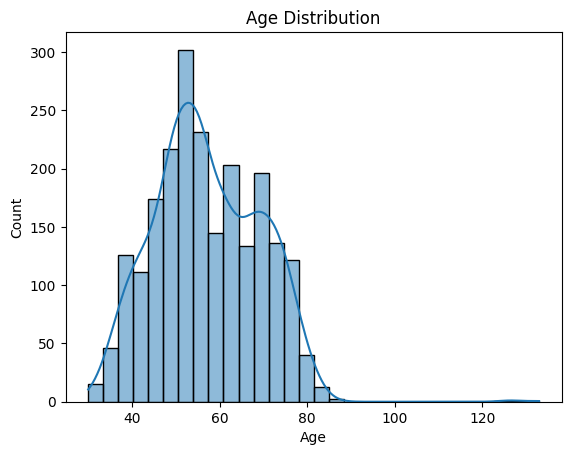

In [36]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

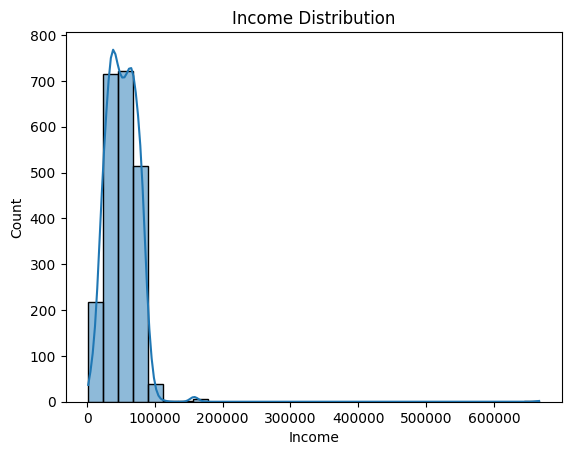

In [40]:
sns.histplot(df["Income"], bins =30, kde=True)
plt.title("Income Distribution")
plt.show()

Text(0.5, 1.0, 'Total spending Distribution')

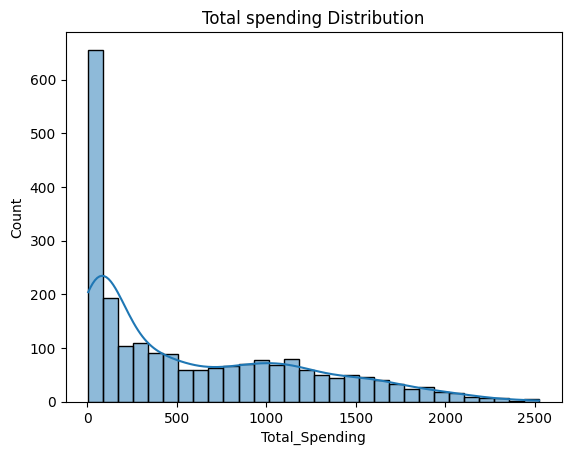

In [41]:
sns.histplot(df["Total_Spending"], bins = 30, kde=True)
plt.title("Total spending Distribution")

Text(0.5, 1.0, 'Income by Education Level')

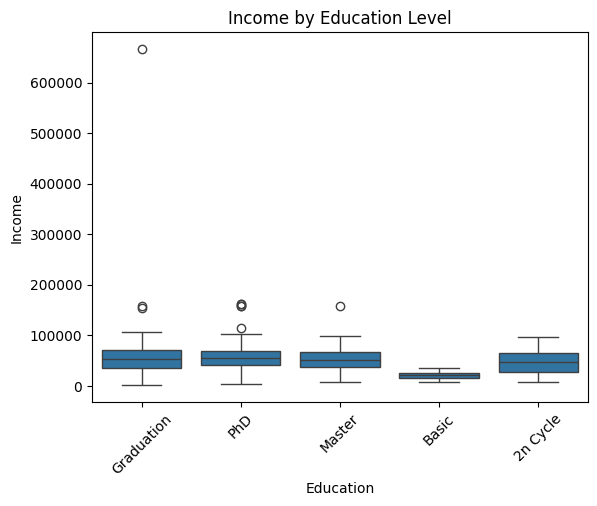

In [43]:
sns.boxplot(x="Education", y="Income", data=df)
plt.xticks(rotation=45)
plt.title("Income by Education Level")

Text(0.5, 1.0, 'Spending by Marital Status')

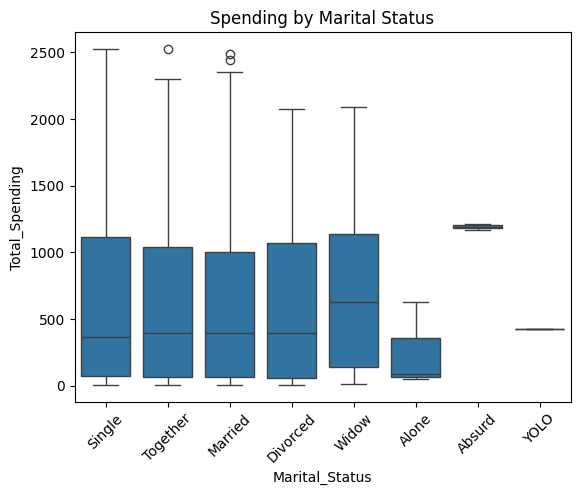

In [44]:
sns.boxplot(x="Marital_Status", y="Total_Spending", data=df)
plt.xticks(rotation=45)
plt.title("Spending by Marital Status")

In [48]:
corr =df[["Income", "Age", "Recency", "Total_Spending", "NumWebPurchases", "NumStorePurchases"]].corr()

In [49]:
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
Total_Spending,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.675181,0.516240,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

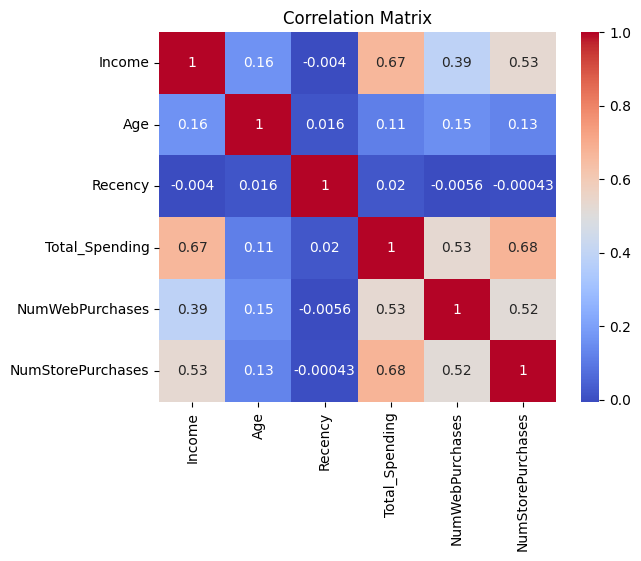

In [50]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

In [51]:
pivot_income = df.pivot_table(values = "Income", index="Education", columns="Marital_Status", aggfunc="mean")


In [52]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


Text(0.5, 1.0, 'Average Income by education ad Marital Status')

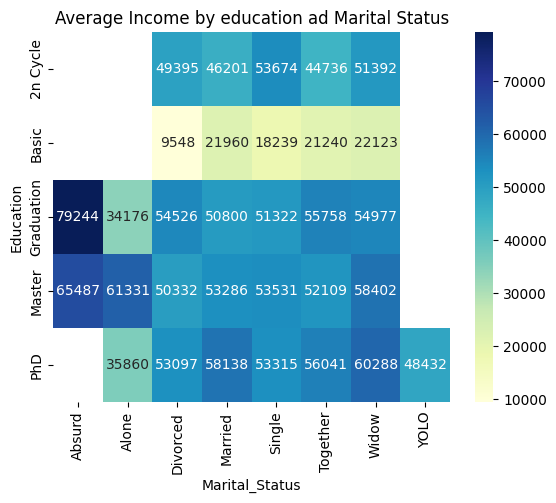

In [53]:
sns.heatmap(pivot_income, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Income by education ad Marital Status")

In [54]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)

In [55]:
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'PhD'),
  Text(1, 0, 'Graduation'),
  Text(2, 0, 'Master'),
  Text(3, 0, '2n Cycle'),
  Text(4, 0, 'Basic')])

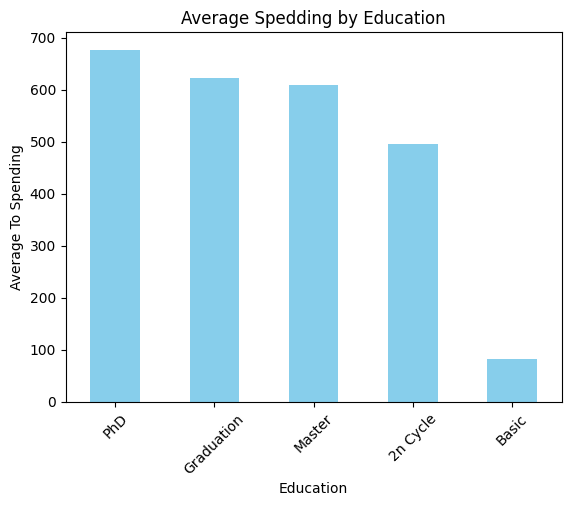

In [56]:
group1.plot(kind="bar", color="skyblue")
plt.title("Average Spedding by Education")
plt.ylabel("Average To Spending")
plt.xticks(rotation=45)

In [57]:
df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1)

In [59]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [60]:
df["AcceptedAny"] = df["AcceptedAny"].apply(lambda x: 1 if x > 0 else 0)

In [61]:
df["AcceptedAny"].unique()

array([1, 0])

In [62]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)

In [63]:
group2


Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Absurd'),
  Text(1, 0, 'YOLO'),
  Text(2, 0, 'Widow'),
  Text(3, 0, 'Alone'),
  Text(4, 0, 'Single'),
  Text(5, 0, 'Divorced'),
  Text(6, 0, 'Married'),
  Text(7, 0, 'Together')])

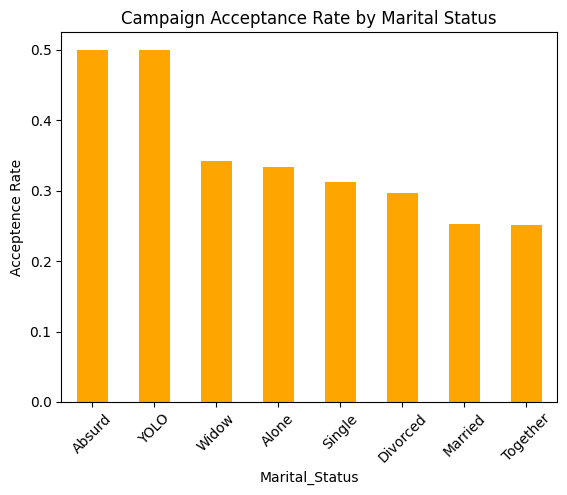

In [65]:
group2.plot(kind="bar", color ="orange")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel("Acceptence Rate")
plt.xticks(rotation=45)

In [66]:
bins = [18,30,40,50,60,70,90]

In [67]:
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]

In [68]:
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [69]:
df["AgeGroup"]

0       60-69
1         70+
2       60-69
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [70]:
group3 =df.groupby("AgeGroup")["Income"].mean()

C:\Users\mbw2025\AppData\Local\Temp\ipykernel_18804\513022088.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 =df.groupby("AgeGroup")["Income"].mean()


In [71]:
group3

AgeGroup
18-29    10960.500000
30-39    47905.475676
40-49    48057.587649
50-59    50479.321534
60-69    55980.030928
70+      58767.083102
Name: Income, dtype: float64

Text(0.5, 0, 'Average Income')

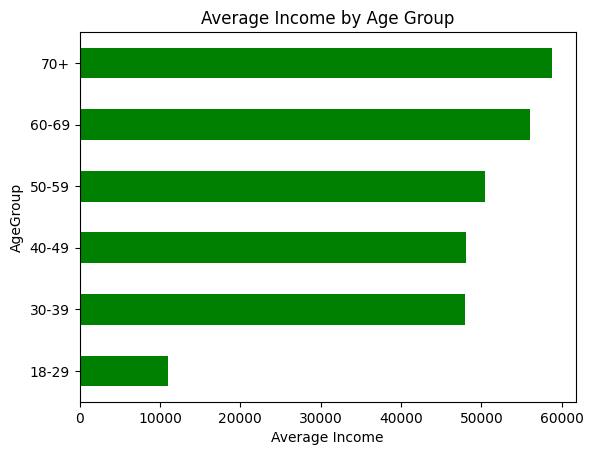

In [72]:
group3.plot(kind="barh", color="green")
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")

In [73]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,69,0,1617,5141,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,72,2,27,4591,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,61,0,776,4790,0,60-69
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,42,1,53,4617,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,45,1,422,4639,0,40-49


In [75]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [78]:
features = ["Age", "Income", "Total_Spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth"]

In [79]:
X =df[features].copy()

In [80]:
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
0,69,58138.0,1617,8,4,7
1,72,46344.0,27,1,2,5
2,61,71613.0,776,8,10,4
3,42,26646.0,53,2,4,6
4,45,58293.0,422,5,6,5
...,...,...,...,...,...,...
2235,59,61223.0,1341,9,4,5
2236,80,64014.0,444,8,5,7
2237,45,56981.0,1241,2,13,6
2238,70,69245.0,843,6,10,3


In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [82]:
X_scaled = scaler.fit_transform(X)

dùng để chuẩn hóa (scaling) dữ liệu số về cùng một thang đo có trung bình bằng 0 (mean = 0) và độ lệch chuẩn bằng 1 (std = 1).

In [83]:
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812,  1.42855332, -0.55414289,
         0.69323197],
       [ 1.23680074, -0.23455948, -0.96235832, -1.12588116, -1.16951781,
        -0.1315745 ],
       [ 0.31882209,  0.76947764,  0.28024985,  1.42855332,  1.29198186,
        -0.54397773],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, -0.76096195,  2.21504423,
         0.28082874],
       [ 1.06989553,  0.67538765,  0.39140438,  0.6987149 ,  1.29198186,
        -0.95638097],
       [ 1.23680074,  0.02470453, -0.7218    , -0.39604274, -0.55414289,
         0.69323197]], shape=(2216, 6))

In [86]:
from sklearn.cluster import KMeans

Đoạn mã from sklearn.cluster import KMeans dùng để nhập (import) thuật toán phân cụm K-Means từ thư viện học máy phổ biến scikit-learn (sklearn), chuẩn bị sẵn sàng để bạn sử dụng trong bài toán phân đoạn khách hàng (Customer Segmentation).

In [87]:
wcss = []

In [88]:
for i in range(2,10):
    kmeans = KMeans(
        n_clusters=i
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

dùng vòng lặp để thực hiện phương pháp Khuỷu tay (Elbow Method) nhằm tìm ra số lượng cụm $K$ tối ưu nhất cho thuật toán K-Means.

for i in range(2,10)::Tạo một vòng lặp chạy qua các giá trị của số cụm $K$ (n_clusters) từ 2 đến 9 (vì hàm range(2, 10) kết thúc trước số 10).

kmeans = KMeans(n_clusters=i):

Khởi tạo mô hình K-Means với số lượng cụm tương ứng là i ở mỗi vòng lặp.

kmeans.fit(X_scaled):

Huấn luyện mô hình K-Means trên tập dữ liệu đã được chuẩn hóa (X_scaled) để tìm ra tọa độ của các tâm cụm (centroids).

wcss.append(kmeans.inertia_):

kmeans.inertia_: Tính toán chỉ số WCSS (Within-Cluster Sum of Squares) – tức là tổng bình phương khoảng cách từ mỗi điểm dữ liệu đến tâm cụm gần nhất của nó. Chỉ số này đo lường độ cô đặc của các cụm (WCSS càng nhỏ nghĩa là các điểm trong cụm càng gom sát nhau).

In [89]:
wcss

[8003.055217364743,
 6798.545466882482,
 6048.863943667258,
 5487.493835270346,
 5128.870105093032,
 4580.452576879027,
 4411.403001603115,
 4131.562948410437]

Text(0, 0.5, 'WCSS')

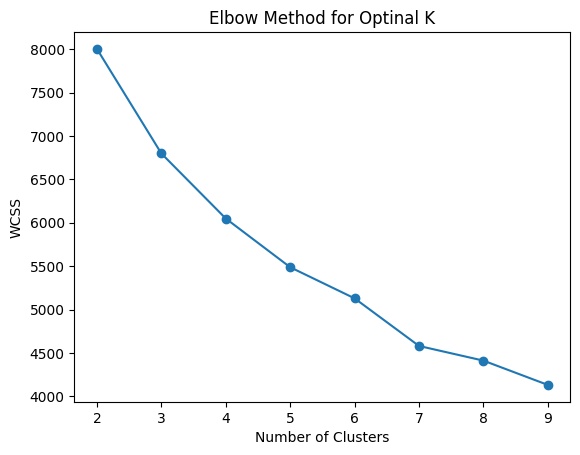

In [90]:
plt.plot(range(2,10), wcss, marker="o")
plt.title("Elbow Method for Optinal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

Khi bạn vẽ đồ thị với trục hoành là số cụm ($K$ từ 2 đến 9) và trục tung là giá trị WCSS, đường cong sẽ giảm dần và uốn cong tạo thành hình "khuỷu tay" (Elbow).

Điểm gãy khúc ở khuỷu tay chính là số lượng cụm tối ưu $K$ mà doanh nghiệp nên chọn (ví dụ: điểm mà tại đó việc tăng thêm số cụm không làm giảm đáng kể WCSS nữa).

In [91]:
kmeans = KMeans(n_clusters=6)
df["Cluster"] = kmeans.fit_predict(X_scaled)

dùng để khởi tạo mô hình K-Means với 6 cụm, tiến hành huấn luyện và gán nhãn cụm cho từng dòng dữ liệu khách hàng trong bảng.

In [92]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,69,0,1617,5141,1,60-69,2
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,72,2,27,4591,0,70+,4
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,61,0,776,4790,0,60-69,3
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,42,1,53,4617,0,40-49,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,45,1,422,4639,0,40-49,2


In [93]:
cluster_summary = df.groupby("Cluster")[features].mean()

In [94]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,
0,45.492908,74622.312057,1304.471631,4.843972,9.148936,2.833333
1,48.246677,30988.992614,99.125554,2.122600,3.069424,6.989660
2,58.956633,57999.928571,812.609694,7.887755,7.107143,6.563776
3,68.852321,68692.949367,1081.493671,5.345992,10.949367,3.746835
4,66.739336,42157.509479,151.876777,2.412322,3.850711,5.523697
5,66.140777,82282.519417,1317.286408,4.237864,5.781553,2.252427


In [95]:
df["Cluster"].value_counts()

Cluster
1    677
4    422
2    392
0    282
3    237
5    206
Name: count, dtype: int64

In [96]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_data[:,0], pca_data[:,1]

Lý do chúng ta cần dùng PCA (Principal Component Analysis - Phân tích thành phần chính) mặc dù đã có bảng số liệu cluster_summary nằm ở chỗ: Bảng số liệu chỉ cho ta biết "con số khô khan", còn PCA giúp ta "nhìn thấy" bức tranh tổng quan bằng hình ảnh.

Trong code của bạn, tập đặc trưng features có tới 6 biến (Age, Income, Total_Spending, NumWebPurchases, NumStorePurchases, NumWebVisitsMonth).

Não bộ con người chỉ có thể tưởng tượng và nhìn thấy không gian tối đa là 2 chiều (2D) hoặc 3 chiều (3D). Bạn không thể vẽ một biểu đồ không gian 6 chiều để xem các nhóm khách hàng nằm ở đâu được.

Vai trò của PCA: Nén 6 chiều dữ liệu phức tạp đó xuống còn 2 chiều (PCA1 và PCA2) nhưng vẫn giữ lại được lượng thông tin (độ biến thiên) lớn nhất của dữ liệu.

In [97]:
pca_data

array([[ 1.1051798 ,  1.63021086],
       [-1.3340086 , -0.2097081 ],
       [ 1.88841354,  0.63959163],
       ...,
       [ 1.1427021 , -0.66746009],
       [ 1.89843476,  0.30996359],
       [-0.8395238 ,  0.72707899]], shape=(2216, 2))

In [98]:
df["PCA1"]

0       1.105180
1      -1.334009
2       1.888414
3      -1.778358
4       0.008670
          ...   
2235    1.249019
2236    0.506904
2237    1.142702
2238    1.898435
2239   -0.839524
Name: PCA1, Length: 2216, dtype: float64

In [99]:
df["PCA2"]

0       1.630211
1      -0.209708
2       0.639592
3      -0.717599
4      -0.383926
          ...   
2235    0.952250
2236    2.085213
2237   -0.667460
2238    0.309964
2239    0.727079
Name: PCA2, Length: 2216, dtype: float64

Text(0.5, 1.0, 'Customer segmentation (PCA)')

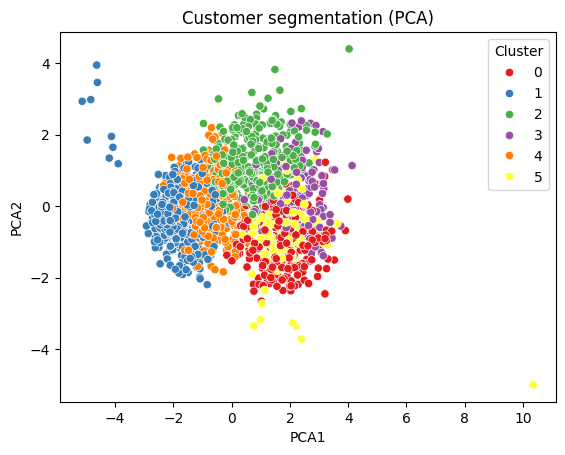

In [100]:
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df, palette="Set1")
plt.title("Customer segmentation (PCA)")

Cluster mới là "hạt nhân" (Core data): Là cột chứa kết quả thực tế (nhãn cụm từ 0 đến 5) mà bạn dùng để gắn vào từng khách hàng, từ đó lập báo cáo, làm chiến lược marketing, hoặc đưa lên ứng dụng Streamlit để dự báo khách hàng mới thuộc nhóm nào.

PCA chỉ là "công cụ hỗ trợ trình diễn" (Visualization tool): Nó giống như một chiếc máy ảnh chụp lại bức tranh đa chiều (6 chiều) của dữ liệu rồi thu nhỏ phẳng lại thành 2 chiều (2D) để con người chúng ta nhìn thấy trên biểu đồ xem các cụm có tách bạch hay không. Nó không dùng để ra quyết định kinh doanh trực tiếp.

In [101]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,
0,45.492908,74622.312057,1304.471631,4.843972,9.148936,2.833333
1,48.246677,30988.992614,99.125554,2.122600,3.069424,6.989660
2,58.956633,57999.928571,812.609694,7.887755,7.107143,6.563776
3,68.852321,68692.949367,1081.493671,5.345992,10.949367,3.746835
4,66.739336,42157.509479,151.876777,2.412322,3.850711,5.523697
5,66.140777,82282.519417,1317.286408,4.237864,5.781553,2.252427


Cluster nao tot ve mang nao
1. Cụm 0: Nhóm "Khách hàng trẻ, thu nhập thấp, ít chi tiêu"
Đặc điểm: Tuổi trung bình trẻ nhất trong các nhóm (~45 tuổi), nhưng thu nhập lại thấp nhất ($22.3k) và tổng chi tiêu cực kỳ khiêm tốn ($130). Số lượt truy cập web hàng tháng cao nhất (hơn 9 lần/tháng).

Ý nghĩa: Đây có thể là học sinh, sinh viên hoặc người mới đi làm. Họ có xu hướng "lướt xem cho vui" (High browsing intent) nhưng khả năng tài chính hạn chế nên tỷ lệ chuyển đổi mua hàng rất thấp.

Chiến lược: Không nên tốn ngân sách chạy quảng cáo sản phẩm cao cấp cho nhóm này. Thay vào đó, hãy đẩy mạnh các sản phẩm giá rẻ, chương trình khuyến mại sinh viên, hoặc dùng retargeting nhẹ nhàng.

2. Cụm 1: Nhóm "Khách hàng trung niên, thu nhập khá nhưng dè dặt chi tiêu"
Đặc điểm: Thu nhập khá cao ($66.7k), nhưng tổng chi tiêu dừng lại ở mức trung bình ($3,098). Số lượng mua hàng qua web và tại cửa hàng đều thấp.

Ý nghĩa: Đây là nhóm khách hàng có tiền nhưng cực kỳ cẩn trọng hoặc chưa thực sự bị thuyết phục bởi các sản phẩm của doanh nghiệp. Họ mua sắm rất ít.

Chiến lược: Tìm hiểu xem họ đang vướng mắc ở điểm gì (chất lượng dịch vụ, chính sách bảo hành, hay chưa thấy sản phẩm phù hợp). Cần tung ra các chiến dịch email marketing giới thiệu lợi ích sản phẩm, review từ chuyên gia để xây dựng lòng tin.

3. Cụm 2: Nhóm "Khách hàng VIP cao cấp, hiện đại (Gia thế & Hào phóng)"
Đặc điểm: Thu nhập rất cao ($79.9k - cao nhất) và tổng chi tiêu khổng lồ (~$8,126). Đặc biệt, nhóm này mua sắm rất mạnh qua cả Website (7.89 lần) lẫn Cửa hàng (7.11 lần).

Ý nghĩa: Đây chính là "con gà đẻ trứng vàng" của doanh nghiệp. Họ có tiền, chuộng công nghệ/mua sắm online nhưng cũng sẵn sàng ghé cửa hàng mua trực tiếp.

Chiến lược: Chăm sóc đặc biệt. Cung cấp dịch vụ khách hàng ưu tiên (VIP support), miễn phí vận chuyển, tặng quà tri ân độc quyền và mời họ tham gia các chương trình khách hàng thân thiết hạng cao nhất.

4. Cụm 3: Nhóm "Khách hàng lớn tuổi truyền thống, mua sắm offline cực mạnh"
Đặc điểm: Lớn tuổi nhất (gần 69 tuổi), thu nhập cao ($68.7k) và tổng chi tiêu rất lớn (~$8,149). Tuy nhiên, số lượng mua hàng tại Cửa hàng vật lý cực kỳ cao (10.95 lần), trong khi lượt truy cập web lại rất thấp (3.75 lần).

Ý nghĩa: Đây là tầng lớp thượng lưu lớn tuổi. Họ có tài chính vững vàng nhưng trung thành với cách mua sắm truyền thống (thích đến tận nơi, nhìn tận mắt, nói chuyện với nhân viên bán hàng) thay vì lướt web.

Chiến lược: Đầu tư trải nghiệm tại cửa hàng (In-store experience), thiết kế không gian mua sắm sang trọng, nhân viên tư vấn tận tình, chu đáo. Tuyệt đối không dồn ngân sách tiếp thị vào kênh online cho nhóm này.

5. Cụm 4: Nhóm "Khách hàng lớn tuổi, thu nhập khá nhưng thắt chặt chi tiêu"
Đặc điểm: Lớn tuổi (~66 tuổi), thu nhập khá ($57.5k) nhưng tổng chi tiêu cực kỳ thấp ($151 - gần như không mua gì).

Ý nghĩa: Nhóm này có thể đã nghỉ hưu, có tài sản tích lũy nhưng lối sống tiết kiệm tối đa, hoặc các sản phẩm hiện tại của doanh nghiệp hoàn toàn không phù hợp với nhu cầu của họ.

Chiến lược: Thận trọng khi phân bổ chi phí tiếp thị. Có thể khảo sát ý kiến xem họ kỳ vọng điều gì hoặc bỏ qua nhóm này để tối ưu hóa nguồn lực cho Cụm 2 và Cụm 3.

6. Cụm 5: Nhóm "Khách hàng bình dân truyền thống"
Đặc điểm: Lớn tuổi (~66 tuổi), thu nhập thấp ($28.3k), chi tiêu thấp ($131). Chủ yếu mua sắm tại cửa hàng truyền thống (5.78 lần) và cực kỳ ít lên web (2.25 lượt/tháng).

Ý nghĩa: Phân khúc khách hàng bình dân, mua sắm dựa trên nhu cầu thiết yếu hằng ngày tại các cửa hàng vật lý gần nhà.

Chiến lược: Áp dụng các chương trình giảm giá trực tiếp tại cửa hàng, combo tiết kiệm, tích điểm đổi quà cơ bản.


In [102]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']